# A/B-тест Т-Банк. Новая оплата ЖКХ
Представьте, что вы продуктовый аналитик команды платежей. Команда запустила A/B тест новой формы оплаты ЖКХ с упрощённым заполнением реквизитов.

**Воронка оплаты ЖКХ:**
1. Открыл форму оплаты → 2. Ввёл реквизиты → 3. Подтвердил платеж → 4. Успешная оплата.

**Ключевая метрика:** Конверсия из шага 1 в шаг 4 (успешная оплата).

**Гипотеза H0**: Новая форма с автозаполнением реквизитов не повлияет на долю успешных оплат ЖКХ.
**Гипотеза H1**: Новая форма с автозаполнением реквизитов увеличит долю успешных оплат ЖКХ.

**Длительность теста:** 30 дней (1–30 апреля 2024)

**Ваша задача:** Проанализировать результаты A/B теста и дать рекомендацию: запускать новую форму на всех пользователей или нет.

**Что нужно сделать:** Провести анализ данных A/B теста и подготовить рекомендацию для продуктовой команды. Данные сплитовались по клиентам, а так же в данных могут встречаться некорректные записи (например, пустые пользователи, аномальные значения) обработайте их соответствующим образом.


## Этапы:
1. Разведочный анализ данных (EDA)
2. Работа с выбросами и некорректными записями
3. Визуализация результатов
4. Статистическая проверка гипотез (с обоснованием выбранного метода)
5. Формулировка рекомендации на основе данныx

## 1. Разведочный анализ данных (EDA)

In [1]:
import pandas as pd
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest

In [2]:
file_path = r'data\dannye.xlsx'
df_users = pd.read_excel(file_path, sheet_name='Пользователи')
df_payments = pd.read_excel(file_path, sheet_name='Платежи')

### Работа с таблицей "Пользователи"

In [3]:
df_users.head()

,user_id,group,age,city,device_type
0,1001,A,31,Москва,ios
1,1002,A,31,Москва,ios
2,1003,A,25,Москва,android
3,1004,A,20,Москва,ios
4,1005,A,34,Москва,ios


In [4]:
df_users.info()

<class 'pandas.DataFrame'>
RangeIndex: 1504 entries, 0 to 1503
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   user_id      1504 non-null   int64
 1   group        1503 non-null   str  
 2   age          1504 non-null   int64
 3   city         1503 non-null   str  
 4   device_type  1504 non-null   str  
dtypes: int64(2), str(3)
memory usage: 58.9 KB


In [5]:
df_users.describe()

,user_id,age
count,1504.000000,1504.000000
mean,1769.787234,32.745346
std,571.592080,8.410915
min,1001.000000,-5.000000
25%,1376.750000,27.000000
50%,1752.500000,33.000000
75%,2128.250000,38.000000
max,9004.000000,150.000000


In [6]:
df_users["age"].sort_values().head()

1501    -5
26      20
23      20
42      20
47      20
Name: age, dtype: int64

In [7]:
df_users["age"].sort_values(ascending=False).head()

1502    150
68       60
817      60
459      58
1480     57
Name: age, dtype: int64

In [8]:
df_users["user_id"].nunique() == len(df_users)

True

In [9]:
df_users["group"].value_counts()

group
A    752
B    751
Name: count, dtype: int64

In [10]:
df_users["city"].value_counts()

city
Москва    595
Регион    514
СПб       394
Name: count, dtype: int64

In [11]:
df_users["device_type"].value_counts()

device_type
android    777
ios        727
Name: count, dtype: int64

Выводы:
1. Отрицательный возраст (min = -5.0): Возраст пользователя не может быть меньше нуля. Это явный технический сбой при логировании или баг в интерфейсе.
2. Аномально высокий возраст (max = 150.0): Человек в возрасте 150 лет физически не может оплачивать ЖКХ. Скорее всего, это пользователи, которые ввели случайные данные, либо техническая «заглушка».
3. Пропущенные значения (Non-Null Count = 1503 из 1504): В столбцах group и city не хватает по одному значению. Пользователя без указанной группы (A или B) невозможно использовать в A/B-тесте.

### Работа с таблицей "Платежи"

In [12]:
df_payments.head()

,payment_id,user_id,group,step1_opened,step2_entered,step3_confirmed,step4_success
0,5001,1001.0,A,2024-04-16 06:06:00,2024-04-16 06:10:00,NaT,NaT
1,5002,1002.0,A,2024-04-12 07:38:00,2024-04-12 07:41:00,NaT,NaT
2,5003,1003.0,A,2024-04-26 20:03:00,2024-04-26 20:07:00,NaT,NaT
3,5004,1004.0,A,2024-04-09 16:02:00,NaT,NaT,NaT
4,5005,1004.0,A,2024-04-04 03:46:00,2024-04-04 03:54:00,2024-04-04 03:57:00,2024-04-04 04:02:00


In [13]:
df_payments.info()

<class 'pandas.DataFrame'>
RangeIndex: 2661 entries, 0 to 2660
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   payment_id       2661 non-null   int64         
 1   user_id          2660 non-null   float64       
 2   group            2661 non-null   str           
 3   step1_opened     2661 non-null   datetime64[us]
 4   step2_entered    2256 non-null   datetime64[us]
 5   step3_confirmed  1719 non-null   datetime64[us]
 6   step4_success    1522 non-null   datetime64[us]
dtypes: datetime64[us](4), float64(1), int64(1), str(1)
memory usage: 145.7 KB


In [14]:
df_payments.describe()

,payment_id,user_id,step1_opened,step2_entered,step3_confirmed,step4_success
count,2661.000000,2660.000000,2661,2256,1719,1522
mean,6433.978579,1760.884211,2024-04-15 17:56:46.854566,2024-04-15 14:21:25.904255,2024-04-15 13:37:05.375218,2024-04-15 12:22:53.534822
min,5001.000000,1001.000000,2024-04-01 00:19:00,2024-04-01 00:23:00,2024-04-01 00:29:00,2024-04-01 00:33:00
25%,5666.000000,1388.000000,2024-04-08 01:30:00,2024-04-07 22:25:45,2024-04-07 19:01:00,2024-04-07 22:22:00
50%,6331.000000,1762.500000,2024-04-15 15:30:00,2024-04-15 05:12:30,2024-04-15 05:23:00,2024-04-14 23:01:00
75%,6996.000000,2135.250000,2024-04-23 13:25:00,2024-04-23 12:43:00,2024-04-23 14:28:00,2024-04-23 11:49:30
max,99003.000000,9004.000000,2024-04-30 23:17:00,2024-04-30 23:20:00,2024-04-30 23:25:00,2024-04-30 23:30:00
std,3203.640974,456.521127,NaN,NaN,NaN,NaN


In [15]:
df_payments["payment_id"].nunique() == len(df_payments)

True

**Выводы:**  
1. Пропуск в user_id (2660 из 2661): В одной строке полностью отсутствует идентификатор пользователя. Мы не знаем, кто совершал эти действия, поэтому такую строчку невозможно склеить с профилями пользователей. Ее нужно удалить.
2. Тип данных user_id (сейчас это float64): Из-за одного пропуска Pandas автоматически превратил идентификаторы в float. После удаления пропуска нужно обязательно вернуть им правильный целочисленный тип (int64), иначе таблицы не склеятся по ключу.
3. Даты соответствуют срокам проведения теста.

## 2. Работа с выбросами и некорректными записями

### Работа с таблицей "Пользователи"

In [16]:
# удаляем строки с пропущенной группой (A/B), тк эту ошибку мв никак не можем исправить
df_users_2 = df_users.dropna(subset=["group", "city"])

In [17]:
df_users_2 = df_users_2.drop(['city', 'device_type'], axis=1, errors='ignore')

In [18]:
# убираем из данных пользователей со странным возрастом
bad_indices = df_users_2[df_users_2["age"].isin([-5, 150])].index
# удаляем эти строки из датафрейма на месте
df_users_2.drop(index=bad_indices, inplace=True)

In [19]:
df_users_2.reset_index(drop=True).info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   user_id  1500 non-null   int64
 1   group    1500 non-null   str  
 2   age      1500 non-null   int64
dtypes: int64(2), str(1)
memory usage: 35.3 KB


In [20]:
df_users_2.describe()

,user_id,age
count,1500.000000,1500.000000
mean,1750.500000,32.699333
std,433.157015,7.795048
min,1001.000000,20.000000
25%,1375.750000,27.000000
50%,1750.500000,33.000000
75%,2125.250000,38.000000
max,2500.000000,60.000000


**Выводы:**  
1. Удалила пропуски (исключены записи без указания тестовой группы или города).
2. Очистила возраст от выбросов (удалены строки с аномальными значениями -5 и 150 лет).
3. Нормализовала диапазон аудитории (после очистки возраст плательщиков распределился в реальных границах от 20 до 60 лет).
4. Оптимизировала структуру таблицы (удалила неиспользуемые столбцы city и device_type, чтобы не перегружать анализ).
5. Итоговый объём выборки составил 1500 пользователей.

### Работа с таблицей "Платежи"

In [21]:
# удаляем строку с пустым user_id
df_payments_2 = df_payments.dropna(subset=['user_id'])

In [22]:
# переводим в int64, так как теперь в столбце нет Null-значений
df_payments_2['user_id'] = df_payments_2['user_id'].astype('int64')

In [23]:
df_payments_2.info()

<class 'pandas.DataFrame'>
RangeIndex: 2660 entries, 0 to 2659
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   payment_id       2660 non-null   int64         
 1   user_id          2660 non-null   int64         
 2   group            2660 non-null   str           
 3   step1_opened     2660 non-null   datetime64[us]
 4   step2_entered    2256 non-null   datetime64[us]
 5   step3_confirmed  1719 non-null   datetime64[us]
 6   step4_success    1522 non-null   datetime64[us]
dtypes: datetime64[us](4), int64(2), str(1)
memory usage: 145.6 KB


In [24]:
# 3. Переводим факты совершения шагов в 1 и 0
df_payments_2['has_step1'] = df_payments_2['step1_opened'].notna().astype(int)
df_payments_2['has_step2'] = df_payments_2['step2_entered'].notna().astype(int)
df_payments_2['has_step3'] = df_payments_2['step3_confirmed'].notna().astype(int)
df_payments_2['has_step4'] = df_payments_2['step4_success'].notna().astype(int)

In [25]:
df_user_funnel = df_payments_2.groupby('user_id').agg({
    'has_step1': 'max',
    'has_step2': 'max',
    'has_step3': 'max',
    'has_step4': 'max'
}).reset_index()

In [26]:
df_user_funnel.head()

,user_id,has_step1,has_step2,has_step3,has_step4
0,1001,1,1,0,0
1,1002,1,1,0,0
2,1003,1,1,0,0
3,1004,1,1,1,1
4,1005,1,1,1,1


**Выводы:**
1. Удалила пропуск в ID пользователя (исключена 1 некорректная запись без указания user_id).
2. Привела типы данных к стандарту (столбец user_id переведен в целочисленный формат int64 для корректного склеивания таблиц).
3. Оцифровала шаги воронки (перевела сложные временные метки открытия, ввода, подтверждения и успеха в простые бинарные флаги 0 и 1).
4. Устранила повторные сессии (схлопнула дублирующиеся клики и попытки оплаты одного и того же клиента через группировку по максимуму).
5. Сформировала продуктовую воронку (итоговый датафрейм df_user_funnel содержит строго по одной чистой строке на каждого уникального пользователя с его предельным прогрессом).

## 3. Визуализация результатов

In [27]:
# функция для построения гистограммы
def sns_plot(df: pd.DataFrame, feature: str, bins: int = 2, color: str = "#3498db", is_bool: bool = False):
    """
    Вывод статистики и построение гистограммы для фичи
    
    Parameters
    ----------
    df : pd.DataFrame
        Датафрейм с данными
    feature : str
        Имя признака для визуализации
    bins : int, default=2
        Количество корзин гистограммы
    color : str, default="#3498db"
        Цвет гистограммы
    is_bool : bool, default=False
        Является ли признак бинарным
    """
    plt.figure(figsize=(10, 5))
    
    # Описательная статистика
    display(df[feature].describe())
    
    # Гистограмма
    sns.histplot(
        data=df,
        x=feature,
        bins=bins,
        color=color,
        edgecolor="black"
    )
    
    # Подписи осей
    plt.title(f"Распределение признака '{feature}'", fontsize=16)
    plt.xlabel(feature, fontsize=12)
    plt.ylabel("Количество", fontsize=12)
    if is_bool:
        plt.xticks([0, 1], ["False", "True"])
    
    plt.show()

### Работа с таблицей "Пользователи"

Text(0, 0.5, 'Число пользователей')

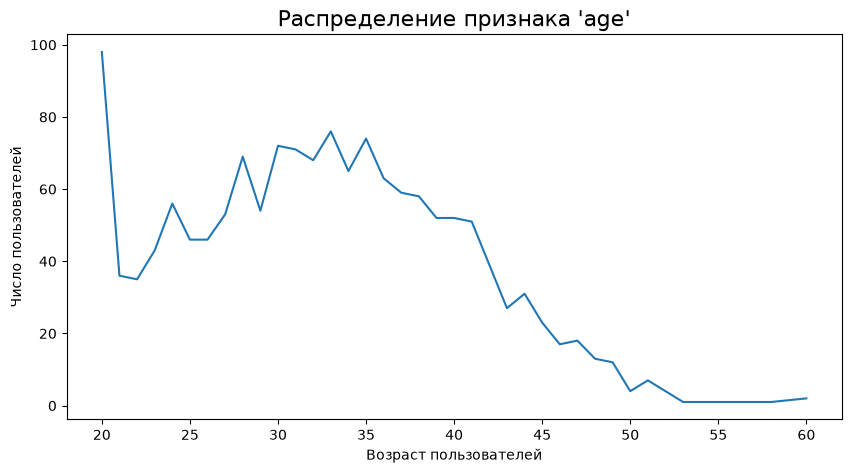

In [28]:
plot_df = df_users_2.groupby('age')['user_id'].count()
plt.figure(figsize=(10, 5))
plt.title("Распределение признака 'age'", fontsize=16)
ax = plot_df.head(100).plot()
ax.set_xlabel('Возраст пользователей')
ax.set_ylabel('Число пользователей')

count     1500
unique       2
top          A
freq       750
Name: group, dtype: object

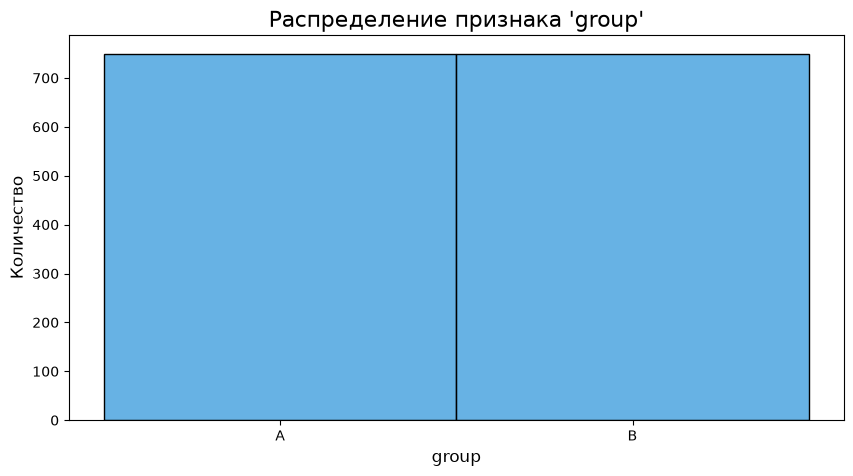

In [29]:
sns_plot(df_users_2, 'group', bins = 2)

In [30]:
df_users_2.groupby('group')['user_id'].count()

group
A    750
B    750
Name: user_id, dtype: int64

**Выводы:**  
1. Пользователи распределены поровну между двумя выборками.

### Работа с таблицей "Платежи"

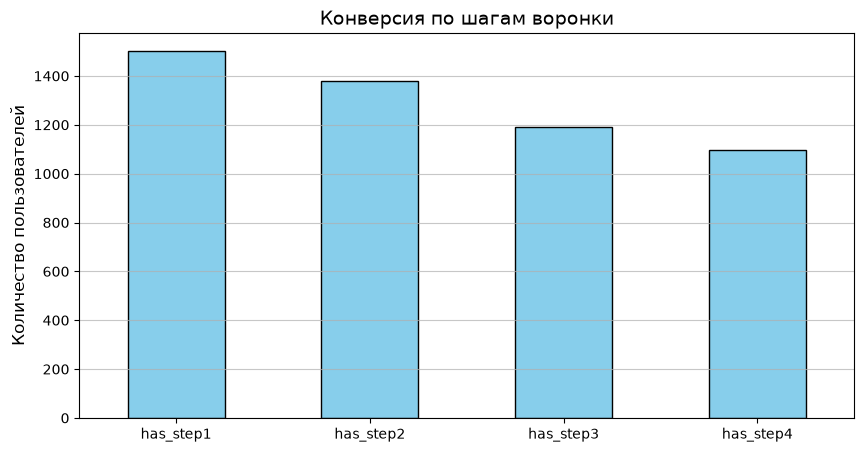

In [31]:
step_counts = df_user_funnel[['has_step1', 'has_step2', 'has_step3', 'has_step4']].sum()

plt.figure(figsize=(10, 5))
step_counts.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Конверсия по шагам воронки', fontsize=14)
plt.ylabel('Количество пользователей', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.7)

plt.show()

In [32]:
step_counts.values

array([1501, 1379, 1193, 1097])

**Выводы:**
1. Оценила общую конверсию в оплату.

### Работа с объединёнными таблицами

In [33]:
df_total = pd.merge(df_users_2, df_user_funnel, on='user_id', how='left')

# заполняем нулями тех пользователей, кто вообще не совершал действий в платежах
df_total[['has_step1', 'has_step2', 'has_step3', 'has_step4']] = df_total[['has_step1', 'has_step2', 'has_step3', 'has_step4']].fillna(0).astype(int)

# считаем итоговые метрики по группам теста
summary = df_total.groupby('group').agg(
    total_users=('user_id', 'count'),
    step1_opened=('has_step1', 'sum'),
    step2_entered=('has_step2', 'sum'),
    step3_confirmed=('has_step3', 'sum'),
    step4_success=('has_step4', 'sum')
).reset_index()

summary['CR_total_%'] = (summary['step4_success'] / summary['step1_opened'] * 100).round(2)
print("Конверсия по шагам")
summary.head()

Конверсия по шагам


,group,total_users,step1_opened,step2_entered,step3_confirmed,step4_success,CR_total_%
0,A,750,750,671,548,493,65.73
1,B,750,750,707,644,603,80.40


<Figure size 1200x600 with 0 Axes>

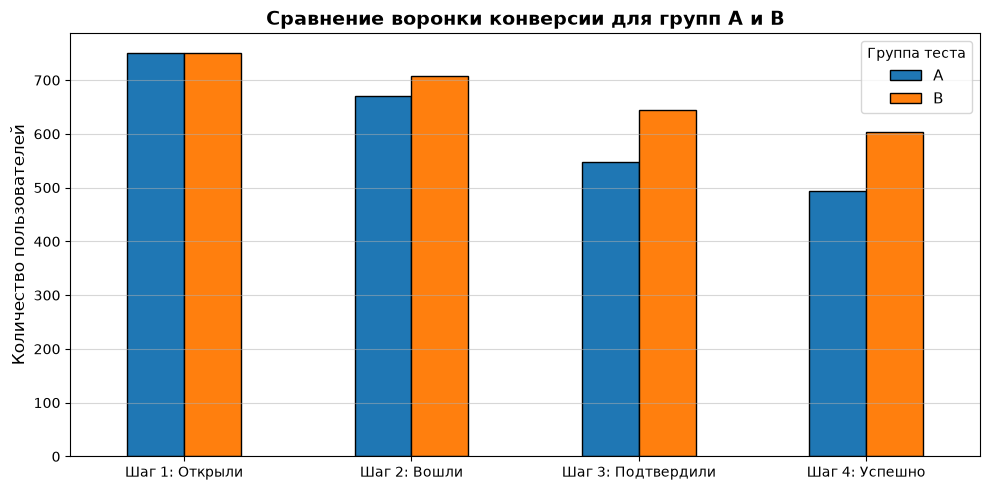

In [34]:
# делаем 'group' индексом и выбираем только столбцы с шагами
plot_data = summary.set_index('group')[[
    'step1_opened', 
    'step2_entered', 
    'step3_confirmed', 
    'step4_success'
]].T  

# строим сгруппированную диаграмму
plt.figure(figsize=(12, 6))
plot_data.plot(kind='bar', figsize=(10, 5), edgecolor='black')

plt.title('Сравнение воронки конверсии для групп A и B', fontsize=14, fontweight='bold')
plt.ylabel('Количество пользователей', fontsize=12)

plt.xticks(
    range(4), 
    ['Шаг 1: Открыли', 'Шаг 2: Вошли', 'Шаг 3: Подтвердили', 'Шаг 4: Успешно'], 
    rotation=0
)

plt.grid(axis='y', alpha=0.5)
plt.legend(title='Группа теста', fontsize=11)

plt.tight_layout()
plt.show()

**Выводы:**  
1. Объединила таблицы пользователей и платежей (связала очищенный профиль клиентов с их действиями в воронке по ключу user_id).
2. Заполнила пропуски нулями (пользователи, которые вообще не открывали форму оплаты, корректно учтены в общем количестве со значениями 0 по всем шагам).
3. Зафиксировала сплитование групп (система распределила пользователей абсолютно поровну: ровно по 750 человек в контрольной группе А и тестовой группе B).
4. Рассчитала конверсию для каждой версии формы (общая конверсия в оплату в группе А составила 65.73%, а в тестовой группе B с автозаполнением реквизитов поднялась до 80.40%).О
5. бнаружила сильный продуктовый прирост (новая форма оплаты показала рост ключевой метрики - конверсия увеличилась на 14.67% в абсолютных значениях).

## 4. Статистическая проверка гипотез (с обоснованием выбранного метода)
Конверсия - это биномиальная метрика, поэтому будем использовать **двухвыборочный z-тест пропорций.** Используем двухвыборочный тест, потому что в эксперименте изменяются и случайны обе величины. 

In [37]:
alpha = 0.05

# фильтруем датасет: берем только тех, кто зашел на форму (has_step1 == 1)
df_funnel_users = df_total[df_total['has_step1'] == 1]

# группируем по группе теста (A/B) и считаем успехи (has_step4)
df_agg = df_funnel_users.groupby('group')['has_step4'].agg(['sum', 'count', 'mean'])

# важно: для надежности явно отсортируем группы в порядке B, затем A, чтобы тест сравнивал именно Тест (B) относительно Контроля (A)
df_agg = df_agg.reindex(['B', 'A'])

n_obs = df_agg['count'].values  # размеры выборок (кол-во открывших форму на Шаге 1)
m_obs = df_agg['sum'].values    # число успехов (кол-во оплативших на Шаге 4)

z_obs, p_val = proportions_ztest(m_obs, 
                                 n_obs, 
                                 value=0, 
                                 alternative='two-sided'
                                )

print(f'Наблюдаемое значение статистики:{z_obs:.3}')
print(f'p_value:{p_val:.3}')


Наблюдаемое значение статистики:6.4
p_value:1.53e-10


## 5. Формулировка рекомендации на основе данныx

**Выводы:**
Полученное значение **p-value = 1.53e-10 значительно меньше** установленного уровня значимости **alpha = 0.05**, значит - **отклоняем нулевую гипотезу H0**. Полученные результаты статистически значимы.   
Внедрение автозаполнения реквизитов (версия B) дает реальный, неслучайный прирост конверсии. Форма рекомендована к раскатке на всех пользователей.

## Итоговые выводы:
1. Провела предобработку данных (успешно зачистила пропуски и технические аномалии возраста в пределах 20–60 лет для 1500 пользователей).
2. Агрегировала логи платежной воронки (перевела сырые временные метки в бинарный формат и схлопнула повторные сессии клиентов до уникальных записей).
3. Оценила общие показатели продукта (выявила, что базовый отток клиентов происходит на этапе перехода от ввода реквизитов к подтверждению платежа).
4. Зафиксировала метрики сплитования групп (подтвердила корректность деления трафика: ровно по 750 человек в контрольной группе А и тестовой группе B).
5. Рассчитала конверсию в успешную оплату (зафиксировала показатель на уровне 65.73% для старой формы А и 80.40% для новой формы B).
6. Выявила сильный продуктовый эффект (абсолютный прирост ключевой метрики за счет автозаполнения реквизитов составил 14.67%).
7. Математически доказала надежность эксперимента (провела двухвыборочный Z-тест пропорций и получила наблюдаемое значение статистики 6.40).
8. Опровергла случайность полученных результатов (зафиксировала сверхнизкий уровень p-value = 1.53e-10, что значительно меньше порога alpha = 0.05.
9. Отклонила нулевую гипотезу эксперимента (подтвердила, что зафиксированные изменения метрик полностью статистически значимы).
10. Приняла финальное продуктовое решение (признала тест успешным и рекомендовала запустить форму с автозаполнением).

**Внедрение автозаполнения реквизитов (версия B) дает реальный, неслучайный прирост конверсии. Форма рекомендована к раскатке на всех пользователей.**